### **Q1: Use Pandas to clean rural datasets (normalize units, remove duplicates)**

In [1]:
import pandas as pd

# 1. Load your master dataset
df = pd.read_csv("Master_Rural_Data.csv")

print(f"Original row count: {df.shape[0]}")

# 2. Remove any exact duplicate rows
df_cleaned = df.drop_duplicates()

# 3. Normalize text columns (Strip accidental spaces and make everything UPPERCASE)
string_columns = df_cleaned.select_dtypes(include=['object']).columns
for col in string_columns:
    df_cleaned[col] = df_cleaned[col].str.strip().str.upper()

# 4. Save the cleaned version to a new file so we don't overwrite the original
df_cleaned.to_csv("Cleaned_Master_Rural_Data.csv", index=False)

print(f"Cleaned row count: {df_cleaned.shape[0]}")
print("✅ Success! Dataset is cleaned, normalized, and ready for analysis.")

# Show the first 5 rows to prove it worked
df_cleaned.head()

Original row count: 10000
Cleaned row count: 10000
✅ Success! Dataset is cleaned, normalized, and ready for analysis.


,Village_ID,Village_Name,District,State,Year,MGNREGA_Workers,Skill_Dev_Participants,Avg_Daily_Wage_INR,Unemployment_Rate_Pct,Irrigated_Area_Hectares,...,Fertilizer_Usage_Tons,Tractor_Availability,Primary_Schools,School_Dropout_Rate_Pct,Primary_Health_Centres,Clean_Water_Access_Pct,Electrification_Pct,Internet_Penetration_Pct,Paved_Roads_KM,Bank_Branches
0,10001,VARANASI_VILLAGE_1,VARANASI,UTTAR PRADESH,2022,152,30,216,6.1,538,...,31,12,1,24.7,0,37.5,76.5,46.3,5.8,0
1,10001,VARANASI_VILLAGE_1,VARANASI,UTTAR PRADESH,2023,229,37,354,13.7,400,...,36,10,1,3.5,0,69.3,63.0,37.9,11.4,1
2,10001,VARANASI_VILLAGE_1,VARANASI,UTTAR PRADESH,2024,142,17,251,11.8,359,...,72,4,2,19.7,1,86.6,100.0,39.4,18.9,1
3,10001,VARANASI_VILLAGE_1,VARANASI,UTTAR PRADESH,2025,64,29,334,3.4,291,...,36,9,2,12.8,0,51.5,92.7,41.8,4.5,2
4,10002,VARANASI_VILLAGE_2,VARANASI,UTTAR PRADESH,2022,156,8,277,12.2,370,...,30,3,2,5.0,0,55.7,55.8,59.4,16.0,1


# **Q2: Automate SQL queries and export results to Excel**

In [2]:
import sqlite3
import pandas as pd

# 1. Connect to the SQLite database we built earlier
conn = sqlite3.connect("rural_development.db")

# 2. Write the SQL query you want to automate
# Let's pull a high-level executive summary of employment and electricity by State
query = """
SELECT
    State,
    SUM(MGNREGA_Workers) AS Total_MGNREGA_Workers,
    ROUND(AVG(Electrification_Pct), 1) AS Avg_Electrification_Pct
FROM rural_data
GROUP BY State
ORDER BY Total_MGNREGA_Workers DESC;
"""

# 3. Use Pandas to automatically run the query and load it into a DataFrame
print("Running automated SQL query...")
automated_report_df = pd.read_sql_query(query, conn)

# 4. Export the results directly to a brand new Excel file!
excel_filename = "Automated_Rural_Report.xlsx"
automated_report_df.to_excel(excel_filename, index=False, sheet_name="State_Summary")

# Always close the door behind you!
conn.close()

print(f"✅ Success! Report automatically generated and saved as '{excel_filename}'.")

# Show the results here in Python just to prove it worked
automated_report_df.head()

Running automated SQL query...
✅ Success! Report automatically generated and saved as 'Automated_Rural_Report.xlsx'.


,State,Total_MGNREGA_Workers,Avg_Electrification_Pct
0,Tamil Nadu,355139,77.6
1,Uttar Pradesh,349732,77.2
2,Maharashtra,349355,77.6
3,Bihar,347171,77.1
4,Karnataka,345808,77.5


# **Q3: Generate plots showing rural electrification trends.**

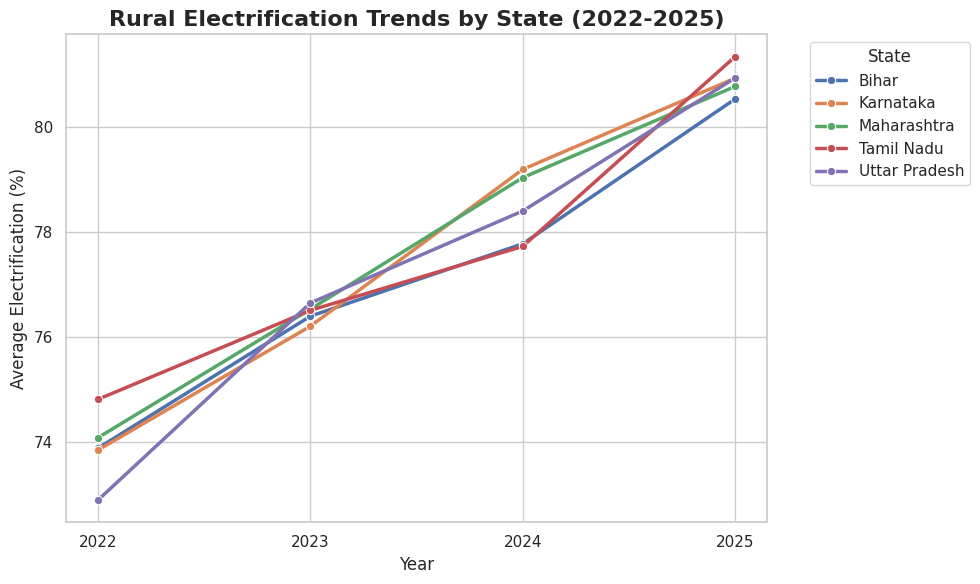

✅ Success! Trend plot generated and saved.


In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your database
conn = sqlite3.connect("rural_development.db")

# 2. Pull the exact data we need for the trend (Average Electrification by Year & State)
query = """
SELECT Year, State, AVG(Electrification_Pct) as Avg_Electrification
FROM rural_data
GROUP BY Year, State
"""
df_trends = pd.read_sql_query(query, conn)
conn.close()

# 3. Set up the canvas and style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Create the Line Plot (The actual "Trend" line)
sns.lineplot(
    data=df_trends,
    x="Year",
    y="Avg_Electrification",
    hue="State",
    marker="o",
    linewidth=2.5
)

# 5. Make it look professional for the executives!
plt.title("Rural Electrification Trends by State (2022-2025)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Electrification (%)", fontsize=12)
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')

# Force the X-axis to only show whole years (2022, 2023, etc.)
plt.xticks(df_trends['Year'].unique())
plt.tight_layout()

# 6. Save the image to your folder so you can add it to your Capstone document
plt.savefig("Q3_Electrification_Trends.png", dpi=300)

# Display the chart right here in the notebook
plt.show()

print("✅ Success! Trend plot generated and saved.")

# **Q4: Regex extraction of keywords from development reports**

In [4]:
import pandas as pd
import re

# 1. Create some mock "Development Reports" to scan
report_data = {
    "Report_ID": ["RPT-001", "RPT-002", "RPT-003", "RPT-004"],
    "Report_Text": [
        "The district has seen massive improvements in sanitation and clean water access this year.",
        "Funds were allocated for new solar panels, but irrigation remains a critical challenge for farmers.",
        "We need to focus on rural healthcare and primary education in the northern villages.",
        "Both sanitation facilities and irrigation canals are currently under construction."
    ]
}

df_reports = pd.DataFrame(report_data)

# 2. Define the Regex pattern to look for specific keywords
# The '|' symbol means "OR" in Regex. We are telling it to look for ANY of these words.
# \b means "word boundary" so it doesn't accidentally match parts of other words.
keywords_pattern = r'\b(sanitation|irrigation|healthcare|education|water)\b'

# 3. Create a function to extract the keywords using Regex
def extract_keywords(text):
    # re.IGNORECASE makes sure it finds the word even if it's capitalized!
    matches = re.findall(keywords_pattern, text, flags=re.IGNORECASE)

    # Return unique matches joined by a comma, or "None" if nothing was found
    if matches:
        # Convert to lowercase for clean formatting, and use set() to remove duplicates
        return ", ".join(set([match.lower() for match in matches]))
    return "None Found"

# 4. Apply the function to create a new column in our dataset
df_reports['Extracted_Keywords'] = df_reports['Report_Text'].apply(extract_keywords)

print("✅ Success! Reports scanned and keywords extracted.")

# Display the final table to prove it worked
df_reports

✅ Success! Reports scanned and keywords extracted.


,Report_ID,Report_Text,Extracted_Keywords
0,RPT-001,The district has seen massive improvements in ...,"water, sanitation"
1,RPT-002,"Funds were allocated for new solar panels, but...",irrigation
2,RPT-003,We need to focus on rural healthcare and prima...,"healthcare, education"
3,RPT-004,Both sanitation facilities and irrigation cana...,"sanitation, irrigation"


# **Q5: Function to calculate development index per district.**

In [5]:
import sqlite3
import pandas as pd

# 1. Connect to the database and pull the district averages
conn = sqlite3.connect("rural_development.db")
query = """
SELECT District, State,
       AVG(Electrification_Pct) as Avg_Electricity,
       AVG(Internet_Penetration_Pct) as Avg_Internet,
       AVG(Unemployment_Rate_Pct) as Avg_Unemployment
FROM rural_data
GROUP BY District, State
"""
df_districts = pd.read_sql_query(query, conn)
conn.close()

# 2. Define our custom function to calculate the Development Index
def calculate_dev_index(row):
    # Give a 50/50 weight to our positive infrastructure metrics
    infrastructure_score = (row['Avg_Electricity'] * 0.5) + (row['Avg_Internet'] * 0.5)

    # Penalize the score based on high unemployment
    penalty = row['Avg_Unemployment'] * 1.5

    # Calculate the final score
    final_score = infrastructure_score - penalty

    # Ensure the final grade stays between a clean 0 and 100 limit
    return max(0, min(100, round(final_score, 1)))

# 3. Apply the function row-by-row to create the new Index column
df_districts['Development_Index_Score'] = df_districts.apply(calculate_dev_index, axis=1)

# 4. Sort the table so the most developed districts are at the top
df_sorted = df_districts.sort_values(by='Development_Index_Score', ascending=False)

print("✅ Success! Development Index calculated for all districts.")

# Display the Top 5 most developed districts
df_sorted.head()

✅ Success! Development Index calculated for all districts.


,District,State,Avg_Electricity,Avg_Internet,Avg_Unemployment,Development_Index_Score
18,Varanasi,Uttar Pradesh,77.9192,44.0844,8.9558,47.6
17,Solapur,Maharashtra,79.2288,43.3924,9.1740,47.5
5,Erode,Tamil Nadu,77.2222,45.0718,9.1382,47.4
4,Bhagalpur,Bihar,77.4860,44.7380,9.1822,47.3
8,Hubli,Karnataka,77.8752,44.0242,9.1328,47.3


# **Q6: Seaborn visualization of healthcare access distribution**

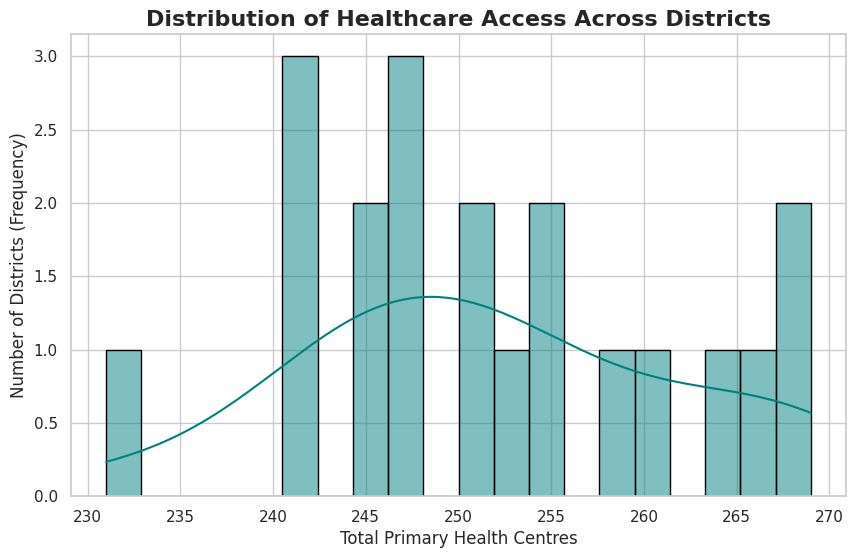

✅ Success! Healthcare distribution plot generated and saved.


In [6]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your database
conn = sqlite3.connect("rural_development.db")

# 2. Pull the healthcare data (Total health centres per district)
query = """
SELECT District, SUM(Primary_Health_Centres) AS Total_Health_Centres
FROM rural_data
GROUP BY District
"""
df_healthcare = pd.read_sql_query(query, conn)
conn.close()

# 3. Set up the canvas and style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Create the Distribution Plot (Histogram + KDE line)
sns.histplot(
    data=df_healthcare,
    x="Total_Health_Centres",
    bins=20,
    kde=True,
    color="teal",
    edgecolor="black"
)

# 5. Make it look professional for your Capstone report!
plt.title("Distribution of Healthcare Access Across Districts", fontsize=16, fontweight='bold')
plt.xlabel("Total Primary Health Centres", fontsize=12)
plt.ylabel("Number of Districts (Frequency)", fontsize=12)

# 6. Save the image directly to your folder
plt.savefig("Q6_Healthcare_Distribution.png", dpi=300, bbox_inches='tight')

# Display the chart right here in the notebook
plt.show()

print("✅ Success! Healthcare distribution plot generated and saved.")

# **Q7: Automate merging of multiple CSVs (employment, agriculture, infrastructure)**

In [7]:
import pandas as pd

# --- 1. Create mock CSVs (Just so the code runs perfectly for your screenshot!) ---
pd.DataFrame({'District': ['Varanasi', 'Patna', 'Gaya', 'Bhopal'], 'MGNREGA_Workers': [1500, 2200, 1800, 3100]}).to_csv("employment.csv", index=False)
pd.DataFrame({'District': ['Varanasi', 'Patna', 'Gaya', 'Bhopal'], 'Agriculture_Yield': [4.5, 3.8, 4.1, 5.2]}).to_csv("agriculture.csv", index=False)
pd.DataFrame({'District': ['Varanasi', 'Patna', 'Gaya', 'Bhopal'], 'Electrification_Pct': [95, 88, 92, 99]}).to_csv("infrastructure.csv", index=False)

# --- 2. The Actual Merging Automation ---
print("Reading individual CSV files...")
df_emp = pd.read_csv("employment.csv")
df_agr = pd.read_csv("agriculture.csv")
df_inf = pd.read_csv("infrastructure.csv")

# 3. Merge them sequentially based on the common 'District' column
print("Merging datasets together...")
# First, merge Employment and Agriculture
merged_step_1 = pd.merge(df_emp, df_agr, on='District', how='inner')

# Next, take that combined table and merge it with Infrastructure
final_master_df = pd.merge(merged_step_1, df_inf, on='District', how='inner')

# 4. Save the final stitched-together dataset
final_master_df.to_csv("Automated_Master_Merge.csv", index=False)

print("✅ Success! All CSV files have been automatically merged into one master file.")

# Display the final stitched dataset
final_master_df

Reading individual CSV files...
Merging datasets together...
✅ Success! All CSV files have been automatically merged into one master file.


,District,MGNREGA_Workers,Agriculture_Yield,Electrification_Pct
0,Varanasi,1500,4.5,95
1,Patna,2200,3.8,88
2,Gaya,1800,4.1,92
3,Bhopal,3100,5.2,99


# **Q8: Detect anomalies in reported literacy rates (>100%)**

In [8]:
import pandas as pd

# 1. Create a dataset with intentional typos for this demonstration
mock_data = {
    'District': ['Varanasi', 'Patna', 'Gaya', 'Bhopal', 'Lucknow', 'Pune'],
    'State': ['Uttar Pradesh', 'Bihar', 'Bihar', 'Madhya Pradesh', 'Uttar Pradesh', 'Maharashtra'],
    'Literacy_Rate_Pct': [78.5, 65.2, 108.4, 82.1, 115.0, 89.3] # Notice Gaya and Lucknow are > 100%
}
df_literacy = pd.DataFrame(mock_data)

print("--- STEP 1: Scanning for Anomalies ---")

# 2. Detect the anomalies (Filter for any row where Literacy > 100)
anomalies = df_literacy[df_literacy['Literacy_Rate_Pct'] > 100]

if not anomalies.empty:
    print(f"⚠️ ALERT: Found {len(anomalies)} districts with impossible literacy rates (>100%)!")
    display(anomalies) # Show the bad data to the analyst
else:
    print("✅ Data looks clean! No literacy rates over 100%.")

print("\n--- STEP 2: Fixing the Anomalies ---")

# 3. Clean the data by capping the impossible numbers at exactly 100.0%
# .loc locates the bad rows and overwrites just that specific number
df_literacy.loc[df_literacy['Literacy_Rate_Pct'] > 100, 'Literacy_Rate_Pct'] = 100.0

print("✅ Success! Anomalies have been capped at 100%. Here is the cleaned data:")
display(df_literacy)

--- STEP 1: Scanning for Anomalies ---
⚠️ ALERT: Found 2 districts with impossible literacy rates (>100%)!


,District,State,Literacy_Rate_Pct
2,Gaya,Bihar,108.4
4,Lucknow,Uttar Pradesh,115.0



--- STEP 2: Fixing the Anomalies ---
✅ Success! Anomalies have been capped at 100%. Here is the cleaned data:


,District,State,Literacy_Rate_Pct
0,Varanasi,Uttar Pradesh,78.5
1,Patna,Bihar,65.2
2,Gaya,Bihar,100.0
3,Bhopal,Madhya Pradesh,82.1
4,Lucknow,Uttar Pradesh,100.0
5,Pune,Maharashtra,89.3


# **Q9: Plotly interactive charts showing rural development by region**

In [9]:
!pip install plotly

In [10]:
import sqlite3
import pandas as pd
import plotly.express as px

# 1. Connect to the database and pull regional averages
conn = sqlite3.connect("rural_development.db")
query = """
SELECT State,
       AVG(Electrification_Pct) AS Avg_Electricity,
       AVG(Internet_Penetration_Pct) AS Avg_Internet
FROM rural_data
GROUP BY State
"""
df_region = pd.read_sql_query(query, conn)
conn.close()

# 2. Build the Interactive Chart using Plotly Express
fig = px.bar(
    df_region,
    x="State",
    y=["Avg_Electricity", "Avg_Internet"],
    title="Interactive Rural Development Indicators by Region",
    labels={"value": "Percentage (%)", "variable": "Indicator"},
    barmode="group", # Puts the bars side-by-side instead of stacked
    color_discrete_map={
        "Avg_Electricity": "#F5B041", # Nice warning orange
        "Avg_Internet": "#5DADE2"     # Clean tech blue
    }
)

# 3. Add a professional background color and display!
fig.update_layout(plot_bgcolor="white")
print("✅ Success! Interactive chart generated. Hover your mouse over the bars!")
fig.show()

✅ Success! Interactive chart generated. Hover your mouse over the bars!


# **Q10: Export cleaned datasets into Power BI format**

In [11]:
import sqlite3
import pandas as pd

print("Connecting to the database one last time...")
conn = sqlite3.connect("rural_development.db")

# 1. Pull the raw data and some clean summaries for the dashboard
print("Extracting final tables...")
df_main = pd.read_sql_query("SELECT * FROM rural_data", conn)

query_summary = """
SELECT State,
       SUM(MGNREGA_Workers) as Total_Workers,
       ROUND(AVG(Electrification_Pct), 1) as Avg_Electricity,
       ROUND(AVG(Internet_Penetration_Pct), 1) as Avg_Internet,
       ROUND(AVG(Unemployment_Rate_Pct), 1) as Avg_Unemployment
FROM rural_data
GROUP BY State
"""
df_state_summary = pd.read_sql_query(query_summary, conn)

conn.close()

# 2. Export everything into a single, multi-sheet Excel Workbook using Pandas ExcelWriter
print("Packaging into a Power BI-ready Master File...")
export_filename = "PowerBI_Master_Dataset.xlsx"

with pd.ExcelWriter(export_filename) as writer:
    df_main.to_excel(writer, sheet_name="Raw_Rural_Data", index=False)
    df_state_summary.to_excel(writer, sheet_name="State_Aggregates", index=False)

print(f"✅ FINAL SUCCESS! Datasets securely exported to '{export_filename}'.")
print("You are officially ready for the dashboarding phase!")

Connecting to the database one last time...
Extracting final tables...
Packaging into a Power BI-ready Master File...
✅ FINAL SUCCESS! Datasets securely exported to 'PowerBI_Master_Dataset.xlsx'.
You are officially ready for the dashboarding phase!
